# setup
## imports

In [39]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9' # pre allocates XX% of total GPU instead of the default 75%

pd.set_option('display.max_columns', None)

## common variables

In [40]:
LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

HEART_UB = 'UBERON:0000948'
GENE = 'LMNA'

# gtf = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

## model initialization

In [41]:
model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

print('all_folds model initialized!')

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 7157.52it/s]


all_folds model initialized!


## bed file loader

In [42]:
def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row.name,
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    num_intervals = len(intervals)
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
        print(f'loaded {num_intervals} intervals from bed file that fall within {plot_interval}!')
    else:
        print(f'loaded {num_intervals} intervals from bed file')
    return intervals, df


bed_intervals, bed_df = load_bed_intervals('outputs/predicted_reg_regions_post.bed')
# bed_intervals

loaded 32 intervals from bed file


# run ISM

In [43]:

ism_interval = genome.Interval('chr1', 156_114_711, 156_114_714)

# ism_interval = bed_intervals[0] 
# sequence_interval = ism_interval.resize(32768) 
lmna_context = ism_interval.resize(dna_client.SEQUENCE_LENGTH_100KB)

# sj_variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS']

scorers = [
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITES'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITE_USAGE'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['ATAC'],
]

# print(variant_scorers.RECOMMENDED_VARIANT_SCORERS)


# get all available scorers and remove polyadenylation b/c not available for humans?
# idk whenever i try to use it i get errored out so just take it out b/c we don't really care
scorers = dict(variant_scorers.RECOMMENDED_VARIANT_SCORERS)
scorers_drop = ['SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'POLYADENYLATION']
scorers = {k: v for k, v in scorers.items() if k not in scorers_drop}
scorers = list(scorers.values())
# print(scorers)
# position = scorers.index('PolyadenylationScorer()') 
# print(type(scorers[0]))

variant_scores = model.score_ism_variants( 
    interval=lmna_context, 
    ism_interval=ism_interval, 
    variant_scorers=scorers, 
    organism=dna_client.Organism.HOMO_SAPIENS, 
)




100%|██████████| 9/9 [00:14<00:00,  1.63s/it]


## variant_scores object contents breakdown
variant_scores is the return value of `model.score_ism_variants(...)` It's a nested list of AnnData objects:

  `variant_scores[variant_idx][scorer_idx]`  →  AnnData

**Outer list — one entry per ISM variant**
  Each item is all scores for one alternate allele at one position in ism_interval.
  Length is typically ism_interval_width × 3 (3 non-ref bases per position).

**Inner list — one AnnData per scorer**
  Aligned with the scorers list (here: all RECOMMENDED_VARIANT_SCORERS except
  POLYADENYLATION → 18 scorers). Example access: variant_scores[0][0] = first
  variant, first scorer (ATAC CenterMaskScorer).


  | Field                 | Role                                                                                      |
|-----------------------|--------------------------------------------------------------------------------------------|
| `.X`                  | Score matrix (n_obs, n_tracks) — e.g. ATAC is (1, 167)                                     |
| `.var`                | Track metadata: name, strand, ontology_curie, Assay title, biosample_name, etc.            |
| `.obs`                | Gene rows for gene-centric scorers (gene_name); empty for track scorers                    |
| `.uns['variant']`     | The genome.Variant for that ISM mutation                                                   |
| `.uns['variant_scorer']` | Which scorer produced this AnnData                                                    |


  **Typical indexing in the notebook**

- variant_scores[0][0].X                          # scores
- variant_scores[0][0].uns['variant']             # variant object
- variant_scores[0][4].var['ontology_curie']      # tracks for scorer 4
- [v[0].uns['variant'] for v in variant_scores]   # all variants (via scorer 0)


In AlphaGenome, .var is not AlphaGenome-specific 
  jargon — it comes from AnnData 
  (https://anndata.readthedocs.io/), which
  AlphaGenome uses for variant scores.

  What it is: a pandas DataFrame of track metadata.
  Each row of .var describes one column of the score
  matrix .X.

  So if .X has shape (n_obs, n_tracks):

  | AnnData slot | What it describes                                  |
|--------------|-----------------------------------------------------|
| `.X`         | numeric scores                                      |
| `.obs`       | row metadata (e.g. genes for gene-centric scorers)   |
| `.var`       | column / track metadata                              |




In [34]:
print(variant_scorers.RECOMMENDED_VARIANT_SCORERS.keys())

dict_keys(['ATAC', 'CONTACT_MAPS', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'RNA_SEQ_ACTIVE', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'POLYADENYLATION', 'ATAC_ACTIVE', 'DNASE_ACTIVE', 'CHIP_TF_ACTIVE', 'CHIP_HISTONE_ACTIVE', 'CAGE_ACTIVE', 'PROCAP_ACTIVE'])


In [35]:
print(f'number of variants analyzed: {len(variant_scores)}')
print(f'number of scorers used per variant: {len(variant_scores[0])}')

number of variants analyzed: 9
number of scorers used per variant: 15


In [81]:
import numpy as np
import pandas as pd
from alphagenome.interpretation import ism

def is_gene_centric(adata) -> bool:
    # True when AnnData has per-gene rows (gene_name column and >1 observation)
    # determines if scorer is gene-centric or not
    return "gene_name" in adata.obs.columns and adata.n_obs > 1


def extract_single_track_scalar(adata, col_idx: int, gene_name=GENE) -> float | None:
    """Extract one scalar from a single track column."""
    if is_gene_centric(adata):  # scorer returns one score per gene (if the scorer is gene-centric)
        if gene_name is not None and (adata.obs["gene_name"] == gene_name).any():
            # gene of interest is present: select that row only
            row_mask = adata.obs["gene_name"] == gene_name
            # values for this gene × track column, flattened to 1D
            val = np.asarray(adata[row_mask, col_idx].X).ravel()
        else:
            # gene missing/unspecified: take all rows for this track column
            val = np.asarray(adata[:, col_idx].X).ravel()
    else:
        # non-gene-centric: usually a single observation for the track
        val = np.asarray(adata[:, col_idx].X).ravel()

    # enforce that we extracted exactly one number, if not, throw error
    if val.size != 1:
        raise ValueError(f"Expected 1 value, got shape {val.shape} for col {col_idx}")
    return float(val[0])  # convert the single array element to a Python float


def track_key(adata, col_idx: int, scorer_idx: int, scorers: list) -> str:
    """Stable ID for one heart track."""
    row = adata.var.iloc[col_idx]  # metadata for this track column
    # look up the matching scorer object, if index is in range
    scorer = scorers[scorer_idx] if scorer_idx < len(scorers) else None
    # output modality name (e.g. RNA_SEQ) or UNKNOWN if no scorer
    output_type = scorer.requested_output.name if scorer else "UNKNOWN"
    # base variant-scoring method name or UNKNOWN
    base_scorer = scorer.base_variant_scorer.name if scorer else "UNKNOWN"

    # build a unique, human-readable key from modality, scorer, name, strand, col 
    # to uniquely identify each individual trac
    return (
        f"{output_type}::{base_scorer}::"
        f"{row.get('name', 'NA')}::"
        f"strand={row.get('strand', '.')}::"
        f"col={col_idx}"
    )


def heart_track_mask(adata, tissue_curie=HEART_UB) -> pd.Series:
    """Return boolean mask over .var rows for heart-associated tracks."""
    # sets value to True if track is heart associated
    md = adata.var  # track metadata table (columns = tracks)
    mask = pd.Series(False, index=md.index)  # start with all tracks unmarked

    # Primary: ontology_curie column matches the heart UBERON ID
    if "ontology_curie" in md.columns:
        mask |= md["ontology_curie"].eq(tissue_curie)
        # print(f'{HEART_UB} in ontology_curie column in metadata')

    # Fallback: tissue ID embedded in the track name string
    if "name" in md.columns:
        mask |= md["name"].astype(str).str.contains(tissue_curie, na=False)
        # print(f'{HEART_UB} embedded in name column in metadata')

    # Optional: biosample_name mentions "heart"
    if "biosample_name" in md.columns:
        mask |= md["biosample_name"].astype(str).str.contains("heart", case=False, na=False)
        # print(f' the word heart is embedded in biosample_name column in metadata')

    return mask  # True for heart-associated tracks


def discover_heart_tracks(variant_scores, scorers, tissue_curie=HEART_UB):
    adata0 = variant_scores[0]  # first variant's list of scorer AnnDatas
    tracks = {}  # accumulate track_key -> location/metadata

    for scorer_idx, adata in enumerate(adata0):  # one AnnData per scorer
        # get column indices of heart tracks within this scorer's .var 
        heart_cols = np.where(heart_track_mask(adata, tissue_curie).to_numpy())[0]
        

        if len(heart_cols) == 0:
            print(f'found 0 heart tracks in {scorers[scorer_idx]}')
            continue  # skip scorers with no heart tracks

        for col_idx in heart_cols:  # register each heart track
            key = track_key(adata, col_idx, scorer_idx, scorers)
            tracks[key] = {
                "scorer_idx": scorer_idx,  # which scorer AnnData to read
                "col_idx": int(col_idx),  # which .var / .X column
                "metadata": adata.var.iloc[col_idx],  # full track metadata row
            }
        print(f'found {len(heart_cols)} heart tracks in {scorers[scorer_idx]}')

    return tracks


In [82]:
heart_tracks = discover_heart_tracks(variant_scores, scorers)
print(f"Found {len(heart_tracks)} heart tracks in total")

variants = [v[0].uns["variant"] for v in variant_scores] # for each variant in variant_scores, get the variant info
ism_by_track = {}

for track_key, info in heart_tracks.items():
    scorer_idx = info["scorer_idx"]
    col_idx = info["col_idx"]

    scores = [
        extract_single_track_scalar(v[scorer_idx], col_idx, gene_name="LMNA")
        for v in variant_scores
    ]

    ism_by_track[track_key] = ism.ism_matrix(
        scores,
        variants=variants,
        interval=ism_interval,
    )

# print((ism_by_track.keys()))

found 2 heart tracks in CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)
found 0 heart tracks in ContactMapScorer()
found 3 heart tracks in CenterMaskScorer(requested_output=DNASE, width=501, aggregation_type=DIFF_LOG2_SUM)
found 3 heart tracks in CenterMaskScorer(requested_output=CHIP_TF, width=501, aggregation_type=DIFF_LOG2_SUM)
found 16 heart tracks in CenterMaskScorer(requested_output=CHIP_HISTONE, width=2001, aggregation_type=DIFF_LOG2_SUM)
found 4 heart tracks in CenterMaskScorer(requested_output=CAGE, width=501, aggregation_type=DIFF_LOG2_SUM)
found 0 heart tracks in CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=DIFF_LOG2_SUM)
found 13 heart tracks in GeneMaskLFCScorer(requested_output=RNA_SEQ)
found 13 heart tracks in GeneMaskActiveScorer(requested_output=RNA_SEQ)
found 2 heart tracks in CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=ACTIVE_SUM)
found 3 heart tracks in CenterMaskScorer(requested_out

In [90]:
import pickle
with open("variant_scores.pkl", "wb") as f:
    pickle.dump(variant_scores, f)

In [91]:
# load later
with open("variant_scores.pkl", "rb") as f:
    variant_scores2 = pickle.load(f)

In [95]:
len(variant_scores[0])

15

In [87]:
type(list(ism_by_track.values())[0])

numpy.ndarray

In [75]:
variant_scores[0][0].uns["variant"]

Variant(chromosome='chr1', position=156114712, reference_bases='G', alternate_bases='A', name='')

In [47]:
# Index into first variant and first scorer.
# variant_scores[0][0].X

In [49]:
# list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values())

In [50]:
adata = variant_scores[0][0]

print("X shape:", adata.X.shape)
print("obs columns:", adata.obs.columns.tolist())
print("scorer:", adata.uns.get("variant_scorer"))

mask = adata.var["ontology_curie"] == "UBERON:0000948"
print("matching tracks:", mask.sum())
print(adata.var.loc[mask, ["name", "strand", "ontology_curie", "Assay title"]])

subset = adata.X[:, mask]
print("subset shape:", subset.shape, "size:", subset.size)

X shape: (1, 167)
obs columns: []
scorer: CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)
matching tracks: 0
Empty DataFrame
Columns: [name, strand, ontology_curie, Assay title]
Index: []
subset shape: (1, 0) size: 0


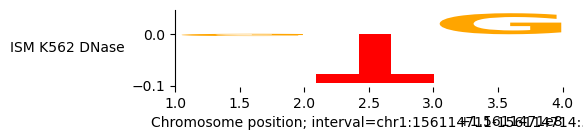

In [70]:
plot_components.plot(
    [
        plot_components.SeqLogo(
            scores=ism_result,
            scores_interval=ism_interval,
            ylabel='ISM K562 DNase',
        )
    ],
    interval=ism_interval,
    fig_width=5,
)

plt.show()

In [105]:


GENE = "LMNA"  # for gene-centric scorers; set None to average all genes


# --- helpers ---

# determine whether a given scorer has the heart UB term present in any of its tracks
# adata is variant_scorers[i]
def has_heart_tracks(adata) -> bool:
    return "ontology_curie" in adata.var.columns and (
        adata.var["ontology_curie"] == HEART_UB
    ).any()


def extract_heart_scalar(adata, gene_name=GENE, how="mean") -> float | None:
    """Collapse heart track columns (and gene rows) to one scalar."""
    track_mask = adata.var["ontology_curie"] == HEART_UB
    if not track_mask.any():
        return None

    sub = adata[:, track_mask]

    # Gene-centric scorer: rows = genes
    if "gene_name" in sub.obs.columns and sub.n_obs > 1:
        if gene_name is not None:
            gene_mask = sub.obs["gene_name"] == gene_name
            if gene_mask.any():
                sub = sub[gene_mask, :]
            # else: fall through and average all genes

    vals = np.asarray(sub.X).ravel()
    if vals.size == 0:
        return None

    if how == "mean":
        return float(vals.mean())
    if how == "max":
        return float(np.abs(vals).max())
    raise ValueError(how)


def scorer_label(adata, idx: int, scorers: list) -> str:
    """Human-readable key for each scorer."""
    if idx < len(scorers):
        s = scorers[idx]
        return f"{s.requested_output.name}::{s.base_variant_scorer.name}"
    return f"scorer_{idx}"


# --- 1) discover which scorers have heart tracks ---

first_variant = variant_scores[0]
heart_scorer_indices = [
    i for i, adata in enumerate(first_variant)
    if has_heart_tracks(adata)
]

print(f"{len(heart_scorer_indices)} / {len(first_variant)} scorers have {HEART}")

for i in heart_scorer_indices:
    adata = first_variant[i]
    n_tracks = (adata.var["ontology_curie"] == HEART).sum()
    print(f"  [{i}] {scorer_label(adata, i, scorers)} — {n_tracks} heart track(s)")
    print(adata.var.loc[adata.var["ontology_curie"] == HEART,
                        ["name", "strand", "Assay title"]])


# --- 2) build ism_matrix per heart scorer ---

ism_results = {}      # scorer_label -> (width, 4) array
ism_metadata = {}     # scorer_label -> extra info

variants = [v[0].uns["variant"] for v in variant_scores]

for scorer_idx in heart_scorer_indices:
    label = scorer_label(first_variant[scorer_idx], scorer_idx, scorers)

    scores = [
        extract_heart_scalar(variant_adatas[scorer_idx], gene_name=GENE)
        for variant_adatas in variant_scores
    ]

    # skip scorers that failed extraction
    if any(s is None for s in scores):
        print(f"Skipping {label}: missing heart scores for some variants")
        continue

    ism_mat = ism.ism_matrix(
        scores,
        variants=variants,
        interval=ism_interval,
    )

    ism_results[label] = ism_mat
    ism_metadata[label] = {
        "scorer_idx": scorer_idx,
        "shape": ism_mat.shape,
        "n_heart_tracks": int((first_variant[scorer_idx].var["ontology_curie"] == HEART).sum()),
    }

print(ism_metadata)

10 / 18 scorers have UBERON:0000948
  [2] DNASE::CENTER_MASK — 1 heart track(s)
                         name strand Assay title
220  UBERON:0000948 DNase-seq      .   DNase-seq
  [4] CHIP_HISTONE::CENTER_MASK — 4 heart track(s)
                                         name strand       Assay title
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  Histone ChIP-seq
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  Histone ChIP-seq
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  Histone ChIP-seq
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  Histone ChIP-seq
  [5] CAGE::CENTER_MASK — 2 heart track(s)
                     name strand Assay title
178  hCAGE UBERON:0000948      +       hCAGE
451  hCAGE UBERON:0000948      -       hCAGE
  [7] RNA_SEQ::GENE_MASK_LFC — 5 heart track(s)
                                  name strand         Assay title
182  UBERON:0000948 polyA plus RNA-seq      +  polyA plus RNA-seq
183       UBERON:0000948 total RNA-seq      +       total 

In [45]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from alphagenome.data import genome


def _sanitize_npz_key(key: str) -> str:
    """NPZ keys must be valid; keep them reversible."""
    return re.sub(r"[^\w\-.]+", "_", key)


def _unsanitize_npz_key(safe_key: str, inverse_map: dict[str, str]) -> str:
    return inverse_map[safe_key]


def save_ism_results(
    path: str | Path,
    *,
    ism_by_track: dict[str, np.ndarray],
    ism_interval: genome.Interval,
    track_summary: pd.DataFrame | None = None,
    variants: list[genome.Variant] | None = None,
    vocabulary: str = "ACGT",
    extra_metadata: dict[str, Any] | None = None,
) -> Path:
    """
    Save ISM matrices + metadata to a reloadable bundle.

    Creates:
      <path>/
        meta.json
        track_summary.csv
        matrices.npz
        variants.csv          (optional)
        key_map.json          (original track_key <-> npz key)
    """
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)

    if not ism_by_track:
        raise ValueError("ism_by_track is empty")

    # --- matrices ---
    key_map = {}
    npz_arrays = {}
    for track_key, mat in ism_by_track.items():
        safe_key = _sanitize_npz_key(track_key)
        if safe_key in npz_arrays:
            raise ValueError(f"NPZ key collision after sanitization: {track_key}")
        key_map[safe_key] = track_key
        npz_arrays[safe_key] = np.asarray(mat, dtype=np.float32)

    np.savez_compressed(path / "matrices.npz", **npz_arrays)

    with open(path / "key_map.json", "w") as f:
        json.dump(key_map, f, indent=2)

    # --- interval + global metadata ---
    meta = {
        "version": 1,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "ism_interval": ism_interval.to_interval_dict(),
        "vocabulary": vocabulary,
        "n_tracks": len(ism_by_track),
        "matrix_shape": list(next(iter(ism_by_track.values())).shape),
        "track_keys": list(ism_by_track.keys()),
    }
    if extra_metadata:
        meta["extra"] = extra_metadata

    with open(path / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    # --- track summary ---
    if track_summary is None:
        track_summary = pd.DataFrame(
            {"track_key": list(ism_by_track.keys())}
        )
    track_summary = track_summary.copy()
    track_summary.to_csv(path / "track_summary.csv", index=False)

    # --- variants (optional) ---
    if variants is not None:
        variant_rows = []
        for v in variants:
            variant_rows.append({
                "chromosome": v.chromosome,
                "position": v.position,
                "reference_bases": v.reference_bases,
                "alternate_bases": v.alternate_bases,
                "name": getattr(v, "name", ""),
                "variant_str": str(v),
            })
        pd.DataFrame(variant_rows).to_csv(path / "variants.csv", index=False)

    return path


def load_ism_results(
    path: str | Path,
) -> dict[str, Any]:
    """
    Reload a bundle written by save_ism_results().

    Returns dict with:
      - ism_by_track
      - ism_interval
      - track_summary
      - variants (or None)
      - meta
      - vocabulary
    """
    path = Path(path)

    with open(path / "meta.json") as f:
        meta = json.load(f)

    with open(path / "key_map.json") as f:
        key_map = json.load(f)  # safe_key -> original track_key

    ism_interval = genome.Interval.from_interval_dict(meta["ism_interval"])
    vocabulary = meta.get("vocabulary", "ACGT")

    track_summary = pd.read_csv(path / "track_summary.csv")

    ism_by_track = {}
    with np.load(path / "matrices.npz") as npz:
        for safe_key in npz.files:
            original_key = key_map[safe_key]
            ism_by_track[original_key] = npz[safe_key]

    variants = None
    variants_path = path / "variants.csv"
    if variants_path.exists():
        vdf = pd.read_csv(variants_path)
        variants = [
            genome.Variant(
                chromosome=row.chromosome,
                position=int(row.position),
                reference_bases=row.reference_bases,
                alternate_bases=row.alternate_bases,
                name=row.name if pd.notna(row.name) else "",
            )
            for row in vdf.itertuples(index=False)
        ]

    return {
        "ism_by_track": ism_by_track,
        "ism_interval": ism_interval,
        "track_summary": track_summary,
        "variants": variants,
        "meta": meta,
        "vocabulary": vocabulary,
    }

In [46]:
bundle_dir = save_ism_results(
    "test_ism_outputs",
    ism_by_track=ism_by_track,
    ism_interval=ism_interval,
    track_summary=track_summary,
    variants=variants,
    extra_metadata={
        "tissue_curie": "UBERON:0000948",
        "gene": "LMNA",
        "note": "one matrix per heart track",
    },
)
print("Saved to:", bundle_dir)

NameError: name 'track_summary' is not defined

In [115]:
# one score matrix per individual heart track

def is_gene_centric(adata) -> bool:
    return "gene_name" in adata.obs.columns and adata.n_obs > 1


def extract_single_track_scalar(adata, col_idx: int, gene_name=GENE) -> float | None:
    """Extract one scalar from a single track column."""
    if is_gene_centric(adata): # determine if the scorer is gene centric or not
        if gene_name is not None and (adata.obs["gene_name"] == gene_name).any(): # if there is a defined gene name and it is found within the data
            row_mask = adata.obs["gene_name"] == gene_name
            val = np.asarray(adata[row_mask, col_idx].X).ravel()
        else:
            # fallback: mean across all genes for this track
            val = np.asarray(adata[:, col_idx].X).ravel()
    else:
        val = np.asarray(adata[:, col_idx].X).ravel()

    if val.size != 1:
        raise ValueError(f"Expected 1 value, got shape {val.shape} for col {col_idx}")
    return float(val[0])


def track_key(adata, col_idx: int, scorer_idx: int, scorers: list) -> str:
    """Stable ID for one heart track."""
    row = adata.var.iloc[col_idx]
    scorer = scorers[scorer_idx] if scorer_idx < len(scorers) else None
    output_type = scorer.requested_output.name if scorer else "UNKNOWN"
    base_scorer = scorer.base_variant_scorer.name if scorer else "UNKNOWN"

    return (
        f"{output_type}::{base_scorer}::"
        f"{row.get('name', 'NA')}::"
        f"strand={row.get('strand', '.')}::"
        f"col={col_idx}"
    )


def discover_heart_tracks(variant_scores, scorers, tissue_curie=HEART):
    """
    Returns dict:
      track_key -> {
        "scorer_idx": int,
        "col_idx": int,
        "metadata": Series,
      }
    """
    adata0 = variant_scores[2]
    tracks = {}

    for scorer_idx, adata in enumerate(adata0):
        heart_cols = np.where(adata.var["ontology_curie"] == tissue_curie)[0]

        for col_idx in heart_cols:
            key = track_key(adata, col_idx, scorer_idx, scorers)
            tracks[key] = {
                "scorer_idx": scorer_idx,
                "col_idx": int(col_idx),
                "metadata": adata.var.iloc[col_idx],
            }

    return tracks



In [123]:
adata0 = variant_scores[0]  # not [2]

for scorer_idx, adata in enumerate(adata0):
    scorer = scorers[scorer_idx] if scorer_idx < len(scorers) else None
    label = (
        f"{scorer.requested_output.name}::{scorer.base_variant_scorer.name}"
        if scorer else f"scorer_{scorer_idx}"
    )
    print(f"\n[{scorer_idx}] {label}")
    print("  X shape:", adata.X.shape)
    print("  var columns:", list(adata.var.columns))
    if "ontology_curie" in adata.var.columns:
        n_heart = (adata.var["ontology_curie"] == "UBERON:0000948").sum()
        print(f"  heart tracks (ontology_curie): {n_heart}")
    else:
        print("  NO ontology_curie column")
        if "name" in adata.var.columns:
            print("  sample names:", adata.var["name"].head(3).tolist())


[0] ATAC::CENTER_MASK
  X shape: (1, 167)
  var columns: ['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean']
  heart tracks (ontology_curie): 0

[1] CONTACT_MAPS::CONTACT_MAP
  X shape: (1, 28)
  var columns: ['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'data_source']
  heart tracks (ontology_curie): 0

[2] DNASE::CENTER_MASK
  X shape: (1, 305)
  var columns: ['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean']
  heart tracks (ontology_curie): 1

[3] CHIP_TF::CENTER_MASK
  X shape: (1, 1617)
  var columns: ['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'transcription_factor', 'data_source', 'endedness', 'genetically_modified', 

In [124]:
HEART = "UBERON:0000948"


def heart_track_mask(adata, tissue_curie=HEART_UB) -> pd.Series:
    """Return boolean mask over .var rows for heart-associated tracks."""
    md = adata.var
    mask = pd.Series(False, index=md.index)

    # Primary: ontology_curie column
    if "ontology_curie" in md.columns:
        mask |= md["ontology_curie"].eq(tissue_curie)

    # Fallback: tissue embedded in track name (common in AlphaGenome)
    if "name" in md.columns:
        mask |= md["name"].astype(str).str.contains(tissue_curie, na=False)

    # Optional extra fallbacks
    if "biosample_name" in md.columns:
        mask |= md["biosample_name"].astype(str).str.contains("heart", case=False, na=False)

    return mask


def discover_heart_tracks(variant_scores, scorers, tissue_curie=HEART_UB):
    adata0 = variant_scores[0]  # use first variant
    tracks = {}

    for scorer_idx, adata in enumerate(adata0):
        heart_cols = np.where(heart_track_mask(adata, tissue_curie).to_numpy())[0]

        if len(heart_cols) == 0:
            continue  # skip scorers with no heart tracks

        for col_idx in heart_cols:
            key = track_key(adata, col_idx, scorer_idx, scorers)
            tracks[key] = {
                "scorer_idx": scorer_idx,
                "col_idx": int(col_idx),
                "metadata": adata.var.iloc[col_idx],
            }

    return tracks


def has_heart_tracks(adata, tissue_curie=HEART) -> bool:
    return heart_track_mask(adata, tissue_curie).any()

In [125]:
heart_tracks = discover_heart_tracks(variant_scores, scorers)
print(f"Found {len(heart_tracks)} heart tracks")

variants = [v[0].uns["variant"] for v in variant_scores]
ism_by_track = {}

for track_key, info in heart_tracks.items():
    scorer_idx = info["scorer_idx"]
    col_idx = info["col_idx"]

    scores = [
        extract_single_track_scalar(v[scorer_idx], col_idx, gene_name="LMNA")
        for v in variant_scores
    ]

    ism_by_track[track_key] = ism.ism_matrix(
        scores,
        variants=variants,
        interval=ism_interval,
    )

Found 72 heart tracks


ValueError: Expected 1 value, got shape (2,) for col 217

In [116]:

# --- 1) discover all heart tracks from first variant ---
heart_tracks = discover_heart_tracks(variant_scores, scorers)

print(f"Found {len(heart_tracks)} heart tracks:")
for key, info in heart_tracks.items():
    md = info["metadata"]
    print(f"  {key}")
    print(f"    name={md.get('name')}, strand={md.get('strand')}, assay={md.get('Assay title', 'NA')}")


# --- 2) build one ISM matrix per track ---
variants = [v[0].uns["variant"] for v in variant_scores]

ism_by_track = {}      # track_key -> ndarray (width, 4)
track_tables = []      # optional summary table

for track_key, info in heart_tracks.items():
    scorer_idx = info["scorer_idx"]
    col_idx = info["col_idx"]

    scores = []
    for variant_adatas in variant_scores:
        adata = variant_adatas[scorer_idx]
        scores.append(
            extract_single_track_scalar(adata, col_idx, gene_name=GENE)
        )

    ism_mat = ism.ism_matrix(
        scores,
        variants=variants,
        interval=ism_interval,
    )

    ism_by_track[track_key] = ism_mat

    md = info["metadata"]
    track_tables.append({
        "track_key": track_key,
        "scorer_idx": scorer_idx,
        "col_idx": col_idx,
        "track_name": md.get("name"),
        "strand": md.get("strand"),
        "assay_title": md.get("Assay title", np.nan),
        "biosample_name": md.get("biosample_name", np.nan),
        "histone_mark": md.get("histone_mark", np.nan),
        "shape": ism_mat.shape,
    })

track_summary = pd.DataFrame(track_tables)
track_summary

KeyError: 'ontology_curie'

In [117]:
import numpy as np
import pandas as pd
from alphagenome.interpretation import ism

HEART = "UBERON:0000948"
GENE = "LMNA"  # used only for gene-centric scorers


def is_gene_centric(adata) -> bool:
    return "gene_name" in adata.obs.columns and adata.n_obs > 1


def extract_single_track_scalar(adata, col_idx: int, gene_name=GENE) -> float | None:
    """Extract one scalar from a single track column."""
    if is_gene_centric(adata):
        if gene_name is not None and (adata.obs["gene_name"] == gene_name).any():
            row_mask = adata.obs["gene_name"] == gene_name
            val = np.asarray(adata[row_mask, col_idx].X).ravel()
        else:
            # fallback: mean across all genes for this track
            val = np.asarray(adata[:, col_idx].X).ravel()
    else:
        val = np.asarray(adata[:, col_idx].X).ravel()

    if val.size != 1:
        raise ValueError(f"Expected 1 value, got shape {val.shape} for col {col_idx}")
    return float(val[0])


def track_key(adata, col_idx: int, scorer_idx: int, scorers: list) -> str:
    """Stable ID for one heart track."""
    row = adata.var.iloc[col_idx]
    scorer = scorers[scorer_idx] if scorer_idx < len(scorers) else None
    output_type = scorer.requested_output.name if scorer else "UNKNOWN"
    base_scorer = scorer.base_variant_scorer.name if scorer else "UNKNOWN"

    return (
        f"{output_type}::{base_scorer}::"
        f"{row.get('name', 'NA')}::"
        f"strand={row.get('strand', '.')}::"
        f"col={col_idx}"
    )


def discover_heart_tracks(variant_scores, scorers, tissue_curie=HEART):
    """
    Returns dict:
      track_key -> {
        "scorer_idx": int,
        "col_idx": int,
        "metadata": Series,
      }
    """
    adata0 = variant_scores[0]
    tracks = {}

    for scorer_idx, adata in enumerate(adata0):
        heart_cols = np.where(adata.var["ontology_curie"] == tissue_curie)[0]

        for col_idx in heart_cols:
            key = track_key(adata, col_idx, scorer_idx, scorers)
            tracks[key] = {
                "scorer_idx": scorer_idx,
                "col_idx": int(col_idx),
                "metadata": adata.var.iloc[col_idx],
            }

    return tracks


# --- 1) discover all heart tracks from first variant ---
heart_tracks = discover_heart_tracks(variant_scores, scorers)

print(f"Found {len(heart_tracks)} heart tracks:")
for key, info in heart_tracks.items():
    md = info["metadata"]
    print(f"  {key}")
    print(f"    name={md.get('name')}, strand={md.get('strand')}, assay={md.get('Assay title', 'NA')}")


# --- 2) build one ISM matrix per track ---
variants = [v[0].uns["variant"] for v in variant_scores]

ism_by_track = {}      # track_key -> ndarray (width, 4)
track_tables = []      # optional summary table

for track_key, info in heart_tracks.items():
    scorer_idx = info["scorer_idx"]
    col_idx = info["col_idx"]

    scores = []
    for variant_adatas in variant_scores:
        adata = variant_adatas[scorer_idx]
        scores.append(
            extract_single_track_scalar(adata, col_idx, gene_name=GENE)
        )

    ism_mat = ism.ism_matrix(
        scores,
        variants=variants,
        interval=ism_interval,
    )

    ism_by_track[track_key] = ism_mat

    md = info["metadata"]
    track_tables.append({
        "track_key": track_key,
        "scorer_idx": scorer_idx,
        "col_idx": col_idx,
        "track_name": md.get("name"),
        "strand": md.get("strand"),
        "assay_title": md.get("Assay title", np.nan),
        "biosample_name": md.get("biosample_name", np.nan),
        "histone_mark": md.get("histone_mark", np.nan),
        "shape": ism_mat.shape,
    })

track_summary = pd.DataFrame(track_tables)
track_summary

KeyError: 'ontology_curie'

In [106]:
for i, adata in enumerate(variant_scores[0]):
    df = variant_scorers.tidy_scores([adata])
    heart = df[df["ontology_curie"] == HEART]
    if heart.empty:
        continue
    print(f"\n[{i}] {scorer_label(adata, i, scorers)}")
    print(heart[["output_type", "track_name", "track_strand", "gene_name", "raw_score"]].head())


[2] DNASE::CENTER_MASK
    output_type                track_name track_strand gene_name  raw_score
220       DNASE  UBERON:0000948 DNase-seq            .      None  -0.037826

[4] CHIP_HISTONE::CENTER_MASK
      output_type                                track_name track_strand  \
794  CHIP_HISTONE  UBERON:0000948 Histone ChIP-seq H3K27me3            .   
795  CHIP_HISTONE   UBERON:0000948 Histone ChIP-seq H3K4me1            .   
796  CHIP_HISTONE   UBERON:0000948 Histone ChIP-seq H3K4me3            .   
797  CHIP_HISTONE    UBERON:0000948 Histone ChIP-seq H3K9ac            .   

    gene_name  raw_score  
794      None   0.061814  
795      None  -0.002513  
796      None  -0.003085  
797      None  -0.015601  

[5] CAGE::CENTER_MASK
    output_type            track_name track_strand gene_name  raw_score
178        CAGE  hCAGE UBERON:0000948            +      None  -0.222332
451        CAGE  hCAGE UBERON:0000948            -      None  -0.056083

[7] RNA_SEQ::GENE_MASK_LFC
    output

KeyError: 'ontology_curie'

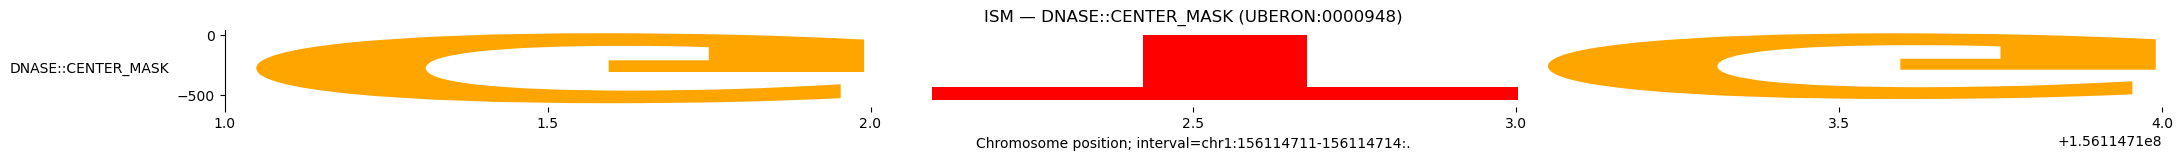

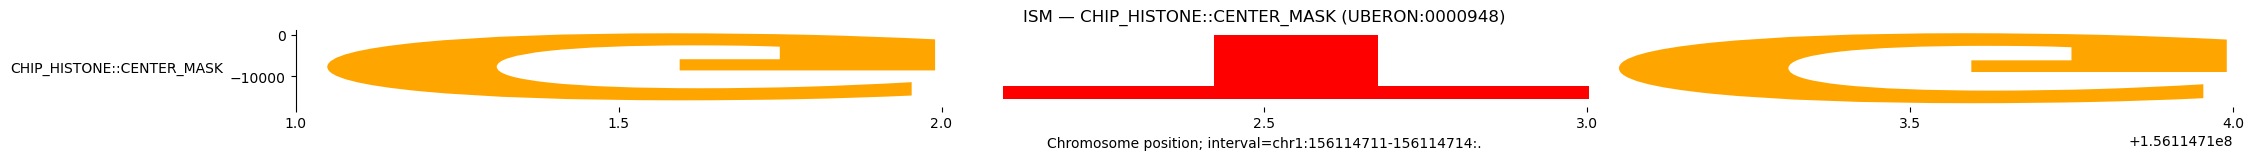

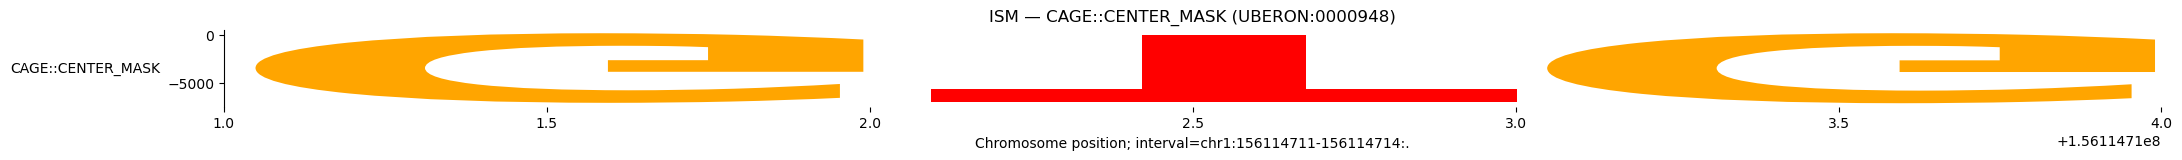

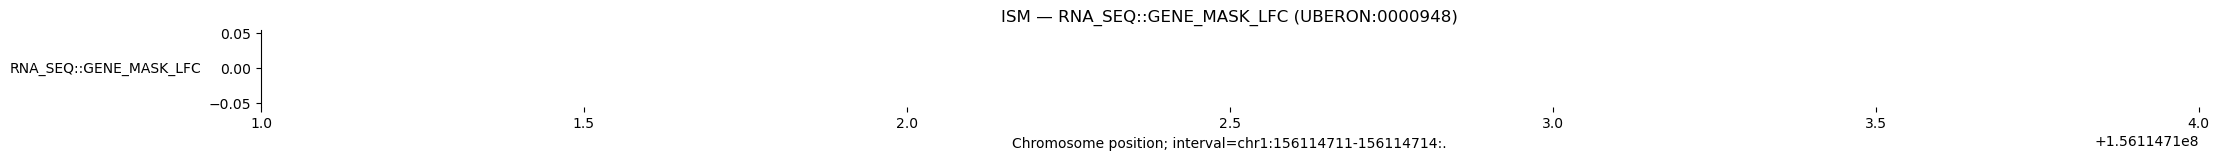

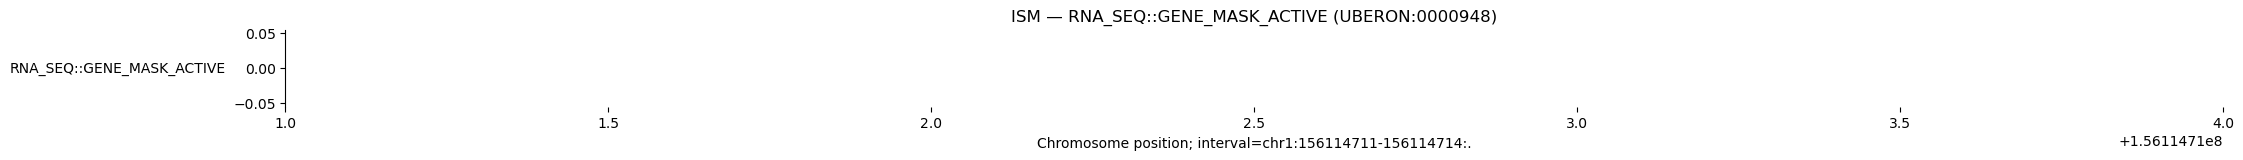

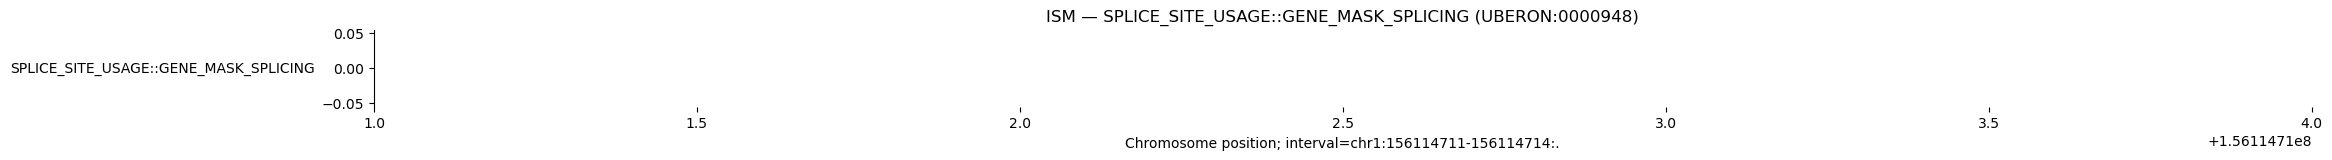

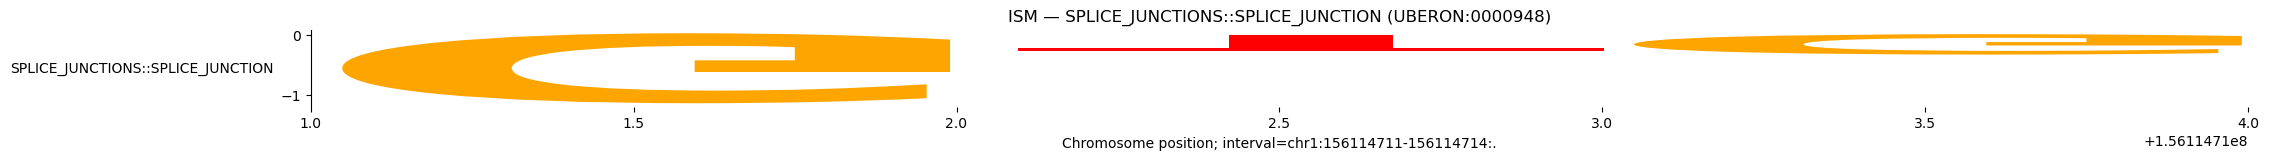

In [107]:
for label, ism_mat in ism_results.items():
    plot_components.plot(
        [plot_components.SeqLogo(
            scores=ism_mat,
            scores_interval=ism_interval,
            ylabel=label,
        )],
        interval=ism_interval,
        title=f"ISM — {label} ({HEART})",
        fig_width=25,
    )
    plt.show()

In [112]:
len(ism_results)

7

In [ ]:
# Score the variants in eval. Takes a minute or so.

scores = dna_model.score_variants(
    intervals=eval_df['interval'].to_list(),
    variants=eval_df['variant'].to_list(),
    variant_scorers=[variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']],
    max_workers=2,
)
clear_output()